In [1]:
import os
os.environ["HF_TOKEN"] = ""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from chronos import BaseChronosPipeline, Chronos2Pipeline
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (14, 6)    

c:\Users\Wasupol\Desktop\Senior_Project_Resource_and_Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = r"C:\Users\Wasupol\Desktop\Senior_Project_Resource_and_Code\EOP Data\eopc04.1962-now_clean.csv"
df = pd.read_csv(file_path, sep=',')
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df = df[(df['Year'] >= 1990) & (df['Year'] <= 2025)].reset_index(drop=True)



chronos_df = df[['Date', 'x_pole']].copy()
chronos_df.rename(columns={'Date': 'timestamp', 'x_pole': 'target'}, inplace=True)
chronos_df["id"] = 'x_pole_series'

In [5]:
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2",device_map="cpu")

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 663.63it/s]


In [6]:
test_size = 30
all_forecasts = []
for i in range(test_size):
    current_train_df = chronos_df.iloc[:-(test_size-i)]

    pred = pipeline.predict_df(current_train_df, prediction_length=1,quantile_levels=[0.1, 0.5, 0.9],id_column="id", timestamp_column="timestamp", target = "target")
    all_forecasts.append(pred)

    if (i + 1) % 5 == 0 or (i + 1) == test_size:
        print(f"  -> Predicted step {i+1}/{test_size} | Date: {pred['timestamp'].iloc[0].date()}")

final_pred_df = pd.concat(all_forecasts, ignore_index=True)
test_df = chronos_df.iloc[-test_size:]

  -> Predicted step 5/30 | Date: 2025-12-06
  -> Predicted step 10/30 | Date: 2025-12-11
  -> Predicted step 15/30 | Date: 2025-12-16
  -> Predicted step 20/30 | Date: 2025-12-21
  -> Predicted step 25/30 | Date: 2025-12-26
  -> Predicted step 30/30 | Date: 2025-12-31


In [8]:
mae = mean_absolute_error(test_df['target'], final_pred_df['0.5'])
print(f"\nMean Absolute Error (MAE) on 1-Day Forecast: {mae:.6f} arcsec")


Mean Absolute Error (MAE) on 1-Day Forecast: 0.000695 arcsec


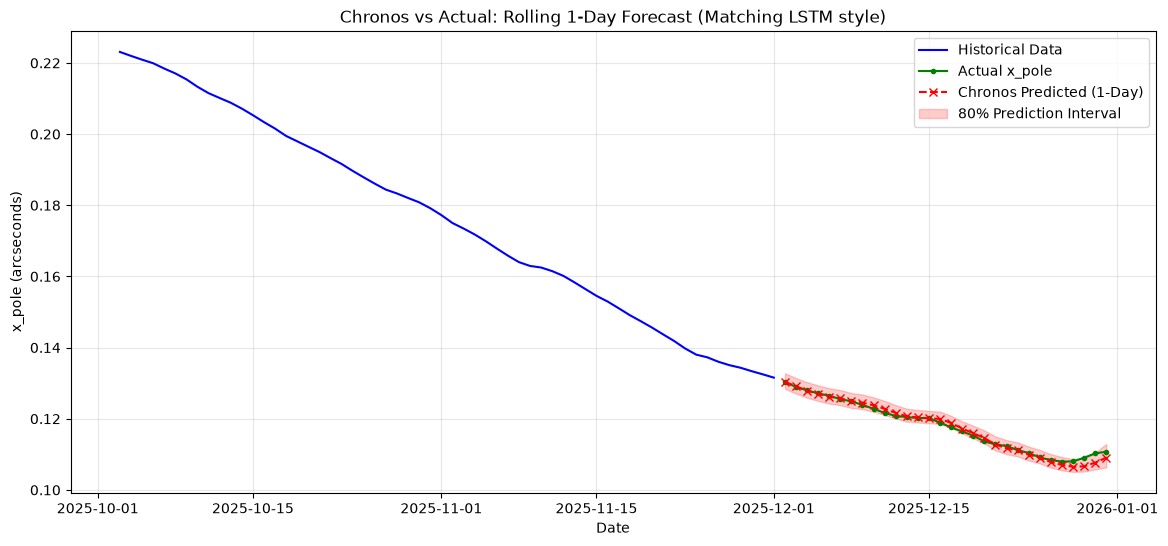

In [9]:
# พล็อตอดีต (ซูมดูแค่ 60 วันก่อนเริ่ม Test)
historical_plot = chronos_df.iloc[-(test_size + 60) : -test_size]
plt.plot(historical_plot['timestamp'], historical_plot['target'], label='Historical Data', color='blue')
# พล็อตเฉลยของจริง (Test)
plt.plot(test_df['timestamp'], test_df['target'], label='Actual x_pole', color='green', marker='.')
# พล็อตค่าที่ Chronos ทำนายได้ทีละวัน (P50 หรือมัธยฐาน)
plt.plot(final_pred_df['timestamp'], final_pred_df['0.5'], label='Chronos Predicted (1-Day)', color='red', linestyle='--', marker='x')
# วาดแถบความเชื่อมั่น
plt.fill_between(
    final_pred_df['timestamp'],
    final_pred_df['0.1'],
    final_pred_df['0.9'],
    color='red', alpha=0.2, label='80% Prediction Interval'
)
plt.title('Chronos vs Actual: Rolling 1-Day Forecast (Matching LSTM style)')
plt.xlabel('Date')
plt.ylabel('x_pole (arcseconds)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()